# Numerical evidence and remaining boundary sensitivity

These studies test the equations actually implemented. They cannot establish
agreement with a real resin, an unmodeled chamber, or a deformed acoustic boundary.
Run `uv run pytest -q` for the independent analytic-limit tests, and
`uv run lenslab validate --out runs/validation_v1` to reproduce the studies below.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from acoustic_freeform.validation import validate_forward_model

ROOT = Path.cwd() if (Path.cwd()/"src").is_dir() else Path.cwd().parent
path = ROOT/"runs/validation_v1/convergence.json"
report = json.loads(path.read_text()) if path.exists() else validate_forward_model(path.parent)
print(report["scope"])
print(json.dumps(report["checks"], indent=2))

Numerical verification of the declared linear, periodic reference only; not a material calibration or experimental error estimate.
{
  "rayleigh_quadrature_converged_below_1e-8": true,
  "time_errors_decrease": true,
  "time_ratio_compatible_with_second_order": true
}


## Acoustic calculation versus an independent half-space integral

The Fourier solver uses a periodic transverse cell. A separate Gauss–Legendre
integration of each square pressure patch evaluates the unbounded Dirichlet
half-space solution at five specified probes:

$$P(\mathbf{x},H)=\int_{\mathrm{patches}} P_s(\mathbf{x}')
\frac{H e^{ikr}(1-ikr)}{2\pi r^3}\,d^2\mathbf{x}',\quad
r=\sqrt{|\mathbf{x}-\mathbf{x}'|^2+H^2}.$$

The kernel follows directly from $-2\partial_zG$ with
$G=e^{ikr}/(4\pi r)$. It is a different implementation from the FFT solver.
Quadrature order 6 versus 10 checks the integral itself. Enlarging the Fourier
cell then measures combined periodic-image and evanescent-truncation differences.
This pressure comparison is not a bound on the error of the final surface.

Independent quadrature relative difference: 7.309156391685285e-14


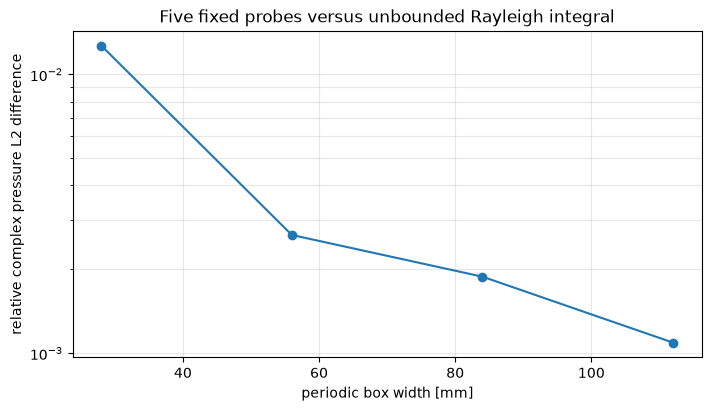

In [2]:
acoustic = report["independent_incident_acoustics"]
print("Independent quadrature relative difference:", acoustic["quadrature_order6_vs10_relative_l2"])
rows = acoustic["periodic_angular_spectrum"]
fig, ax = plt.subplots(figsize=(7, 4), layout="constrained")
ax.semilogy([r["box_m"]*1000 for r in rows],
             [r["complex_pressure_relative_l2"] for r in rows], "o-")
ax.set(xlabel="periodic box width [mm]", ylabel="relative complex pressure L2 difference",
       title="Five fixed probes versus unbounded Rayleigh integral")
ax.grid(True, which="both", alpha=.3)
plt.show()

## Time-step and spatial refinement

The time integration is exact for constant modal forcing. Smooth external
envelopes are approximated at step midpoints. A roughly fourfold reduction in
error after halving the time step is therefore expected until reference error
and stored precision dominate. The plotted reference also has a finite step.

The incident field is band limited by the propagating-only assumption, and its
quadratic traction has at most twice the transverse bandwidth. Above adequate
Nyquist coverage, spatial refinement should saturate for this *linear* model.
That behavior would not be evidence of convergence for nonlinear moving interfaces.

Coarse/middle time-error ratio: 4.266742349055549


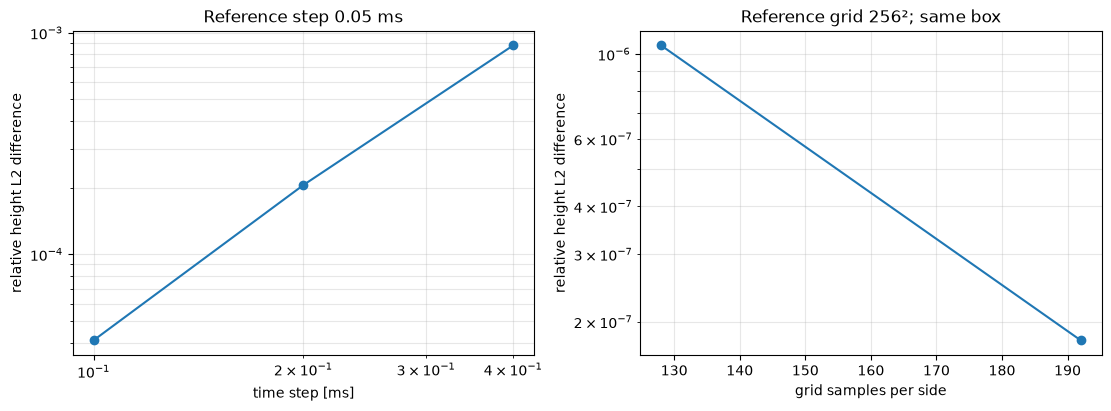

In [3]:
time = report["time_refinement"]
space = report["spatial_refinement"]
fig, axes = plt.subplots(1, 2, figsize=(11, 4), layout="constrained")
axes[0].loglog([r["dt_s"]*1000 for r in time["levels"]],
               [r["relative_l2"] for r in time["levels"]], "o-")
axes[0].set(xlabel="time step [ms]", ylabel="relative height L2 difference",
             title=f"Reference step {time['reference_dt_s']*1000:g} ms")
axes[1].semilogy([r["n"] for r in space["levels"]],
                 [r["relative_l2"] for r in space["levels"]], "o-")
axes[1].set(xlabel="grid samples per side", ylabel="relative height L2 difference",
             title=f"Reference grid {space['reference_n']}²; same box")
for ax in axes:
    ax.grid(True, which="both", alpha=.3)
print("Coarse/middle time-error ratio:", time["coarse_to_middle_error_ratio"])
plt.show()

## Domain enlargement: an unresolved issue for the viscous example

This comparison keeps spatial spacing fixed and compares the same physical
samples in a central square of half-width 4 mm. Snapshots are taken every 5 ms.
Both the acoustics and hydrodynamics change when the box changes: acoustic
replicas, capillary-wave return paths, long-wavelength response, and the periodic
cell's volume constraint are all affected.

The water–air case is observed only to 60 ms. The density-matched Stokes example
is observed to 300 ms and remains appreciably domain sensitive. Treat it as a
periodic verification problem. Do not describe its 56 mm result as a converged
isolated lens. A real finite chamber requires actual depth, walls, volume and
a justified contact-line condition; extending the box indefinitely is not a
replacement for deciding those physical boundaries.

water_air_split_focus
  28 versus 84 mm: 6.8445% relative central height L2
  56 versus 84 mm: 0.4780% relative central height L2
idealized_viscous_pair
  28 versus 84 mm: 32.8640% relative central height L2
  56 versus 84 mm: 8.8454% relative central height L2


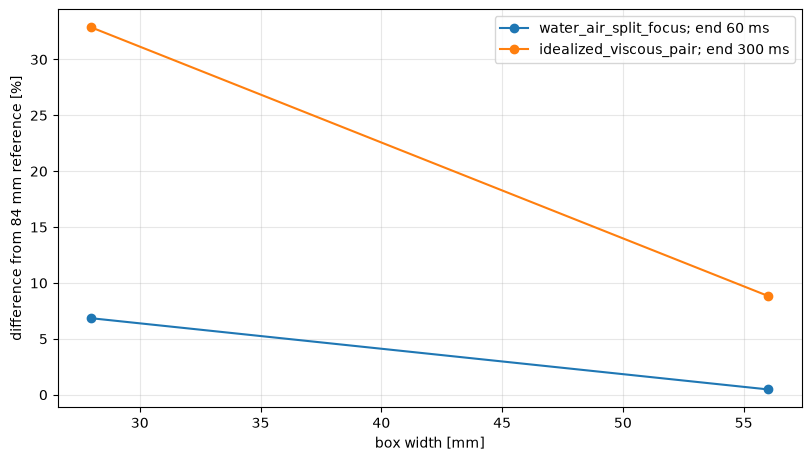

In [4]:
fig, ax = plt.subplots(figsize=(8, 4.5), layout="constrained")
for name, study in report["domain_enlargement"].items():
    x = [r["box_m"]*1000 for r in study["levels"]]
    y = [r["relative_l2"]*100 for r in study["levels"]]
    ax.plot(x, y, "o-", label=f"{name}; end {study['end_s']*1000:g} ms")
    print(name)
    for width, difference in zip(x, y, strict=True):
        print(f"  {width:g} versus 84 mm: {difference:.4f}% relative central height L2")
ax.set(xlabel="box width [mm]", ylabel="difference from 84 mm reference [%]")
ax.legend()
ax.grid(True, alpha=.3)
plt.show()

## What the tests establish

- Normal and oblique acoustic interface matching, flux conservation, and total
  internal reflection agree with analytic formulas.
- Equal fluids give zero interface force; a pressure-release boundary still
  carries radiation force. The latter is checked independently against the
  plane-wave limit in [Chesneau et al.](https://doi.org/10.1103/PhysRevE.106.065104).
- Coherent cancellation and direct combined-field forcing agree with the
  quadratic beam basis; discarding its cross terms changes the result.
- Unforced inviscid modes follow capillary–gravity dispersion and conserve
  energy. Stokes modes follow their analytic exponential decay.
- Reconstructed slow flow is incompressible and matches interface normal speed.
- Volume diagnostics distinguish float64 state conservation from float32 output.

These are meaningful checks, but most are checks of limiting equations. They
do not validate large-amplitude shapes, polymer rheology, acoustic attenuation,
streaming, contact lines, or curing. The current model deliberately exposes
those gaps instead of fitting undocumented coefficients to hide them.